### Import relevant libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from transformer_model import TransformerModel

### Load dataset

In [2]:
df_action = pd.read_csv('../datasets/video_frame_features.csv')

In [3]:
df_action.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_506,feature_507,feature_508,feature_509,feature_510,feature_511,feature_512,video_file_name,label,subset
0,0.006786,-0.3203,0.3706,-0.006176,-0.1317,-0.1846,0.002857,-0.09674,-0.1760,-0.1564,...,-0.04333,-0.2288,0.10486,0.017010,0.2267,0.1471,0.2890,uccrime_Robbery126_x264_trimmed.mp4,abnormal,train
1,-0.009770,-0.3535,0.3987,-0.007480,-0.1360,-0.2051,0.008484,-0.08820,-0.2448,-0.1943,...,-0.10205,-0.2418,0.13650,0.000902,0.1506,0.1405,0.2947,uccrime_Robbery126_x264_trimmed.mp4,abnormal,train
2,0.014490,-0.3508,0.3920,0.002000,-0.1412,-0.1996,0.018860,-0.06880,-0.3167,-0.1968,...,-0.10406,-0.2332,0.13270,0.000527,0.2075,0.1459,0.2861,uccrime_Robbery126_x264_trimmed.mp4,abnormal,train
3,0.013010,-0.3516,0.3909,-0.000943,-0.1395,-0.2040,0.018390,-0.07294,-0.3164,-0.1943,...,-0.10190,-0.2317,0.13220,-0.001555,0.2031,0.1480,0.2852,uccrime_Robbery126_x264_trimmed.mp4,abnormal,train
4,-0.007187,-0.3738,0.4062,-0.004604,-0.1440,-0.2162,0.007750,-0.05478,-0.3389,-0.2120,...,-0.07660,-0.1879,0.12415,-0.010605,0.1663,0.1577,0.2793,uccrime_Robbery126_x264_trimmed.mp4,abnormal,train


In [4]:
df_action.shape

(1324158, 515)

### Explore Data

In [5]:
# Check for missing values
df_action.isnull().sum()

feature_1          0
feature_2          0
feature_3          0
feature_4          0
feature_5          0
                  ..
feature_511        0
feature_512        0
video_file_name    0
label              0
subset             0
Length: 515, dtype: int64

In [ ]:
# Check for label distribution
df_action['label'].value_counts()

label
abnormal    1051114
normal       273044
Name: count, dtype: int64

In [7]:
# Check number of unique video files per label
df_action.groupby('label')['video_file_name'].nunique()

label
abnormal    1079
normal      1070
Name: video_file_name, dtype: int64

In [8]:
# Check number of unieque video files
df_action['video_file_name'].nunique()

2149

In [9]:
# Check number of labels by subset
df_action.groupby('subset')['label'].value_counts()

subset  label   
test    abnormal    168217
        normal       40561
train   abnormal    674931
        normal      187512
val     abnormal    207966
        normal       44971
Name: count, dtype: int64

In [10]:
# Check number of unique video files per subset
df_action.groupby('subset')['video_file_name'].nunique()

subset
test      327
train    1496
val       326
Name: video_file_name, dtype: int64

In [11]:
df_action['subset'].unique()

array(['train', 'val', 'test'], dtype=object)

### Data preparation

In [12]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [13]:
# Helper function to convert series to supervised learning
def series_to_supervised(data, column_names, n_in=1, n_out=1, dropnan=True, n_out_index=None, is_drop_target=False):
    """
    convert series to supervised learning
    Params:
    - n_in: number of timesteps
    - n_out: number of output timestep for prediction | eg. 1 day, 2 days, ....
    - n_out_index: define specific variable for prediction
    - is_drop_target: drop target variable from input variables (to be used for classification problem)
    """
    df_new = pd.DataFrame(data)
    
    if is_drop_target:
        df_input = df_new.drop(columns=[column_names[n_out_index]])
    else:
        df_input = df_new.copy()
    
    n_vars = df_input.shape[1]
    
    cols, names = list(), list()
    
    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df_input.shift(i))
        names += [f'{column_names[j]}(t-{i})' for j in range(n_vars)]
    
    # forecast sequence (t, t+1, ..., t+n)
    for i in range(0, n_out):
        if n_out_index:
            cols.append(df_new.shift(-i).iloc[:, n_out_index])
            if i == 0:
                names += [f'{column_names[n_out_index]}(t)']
            else:
                names += [f'{column_names[n_out_index]}(t+{i})']
        else:
            cols.append(df_new.shift(-i))
            if i == 0:
                names += [f'{column_names[j]}(t)' for j in range(n_vars)]
            else:
                names += [f'{column_names[j]}(t+{i})' for j in range(n_vars)]
    # put it all together
    agg = pd.concat(cols, axis=1)
    agg.columns = names
    # drop rows with NaN values that generated from df_new.shift
    if dropnan:
        agg.dropna(inplace=True)
    
    return agg

In [15]:
# define features
column_names = df_action.columns.tolist()
column_names.remove('video_file_name')
column_names.remove('subset')
column_names

['feature_1',
 'feature_2',
 'feature_3',
 'feature_4',
 'feature_5',
 'feature_6',
 'feature_7',
 'feature_8',
 'feature_9',
 'feature_10',
 'feature_11',
 'feature_12',
 'feature_13',
 'feature_14',
 'feature_15',
 'feature_16',
 'feature_17',
 'feature_18',
 'feature_19',
 'feature_20',
 'feature_21',
 'feature_22',
 'feature_23',
 'feature_24',
 'feature_25',
 'feature_26',
 'feature_27',
 'feature_28',
 'feature_29',
 'feature_30',
 'feature_31',
 'feature_32',
 'feature_33',
 'feature_34',
 'feature_35',
 'feature_36',
 'feature_37',
 'feature_38',
 'feature_39',
 'feature_40',
 'feature_41',
 'feature_42',
 'feature_43',
 'feature_44',
 'feature_45',
 'feature_46',
 'feature_47',
 'feature_48',
 'feature_49',
 'feature_50',
 'feature_51',
 'feature_52',
 'feature_53',
 'feature_54',
 'feature_55',
 'feature_56',
 'feature_57',
 'feature_58',
 'feature_59',
 'feature_60',
 'feature_61',
 'feature_62',
 'feature_63',
 'feature_64',
 'feature_65',
 'feature_66',
 'feature_67',
 'fe

In [16]:
# Define timesteps (number of frames), number of features, and number of output step
timesteps = 30 # select only 10 fps from last 90 frames (3 seconds)
num_features = len(column_names[:-1])
n_steps_out = 1
n_out_index =  -1
n_obs = timesteps * num_features

In [17]:
# Reframe as supervised learning by each video file
subsets = df_action['subset'].unique()
df_by_subset = {}
skip_info = {}

for subset in subsets:
    df_action_subset = df_action[df_action['subset'] == subset]
    video_files = df_action_subset['video_file_name'].unique()

    df_tmp_list = []
    n_skip = 0
    for video_file in video_files:
        df_video = df_action_subset[df_action_subset['video_file_name'] == video_file]
        if df_video.shape[0] < timesteps: # Handle videos with frames less than 30
            # Skip these videos for now
            n_skip += 1
            continue
        elif df_video.shape[0] >= timesteps and df_video.shape[0] < 90: # Handle videos with frames between 30 and 90
            # Select evenly spaced 30 frames from available frames
            idx = np.linspace(0, df_video.shape[0] - 1, timesteps, dtype=int)
            df_selected = df_video.iloc[idx]

        elif df_video.shape[0] >= 90:
            # Select every 3rd frame 
            df_selected = df_video.iloc[::3]

        df_reframed = series_to_supervised(df_selected.drop(columns=['video_file_name', 'subset']), column_names, n_in=timesteps, n_out=n_steps_out, n_out_index=n_out_index, is_drop_target=True)
        df_tmp_list.append(df_reframed)
    
    skip_info[subset] = n_skip
    df_by_subset[subset] = pd.concat(df_tmp_list)

In [82]:
df_by_subset['train'].head()

,feature_1(t-30),feature_2(t-30),feature_3(t-30),feature_4(t-30),feature_5(t-30),feature_6(t-30),feature_7(t-30),feature_8(t-30),feature_9(t-30),feature_10(t-30),...,feature_504(t-1),feature_505(t-1),feature_506(t-1),feature_507(t-1),feature_508(t-1),feature_509(t-1),feature_510(t-1),feature_511(t-1),feature_512(t-1),label
90,0.006786,-0.3203,0.3706,-0.006176,-0.1317,-0.1846,0.002857,-0.09674,-0.1760,-0.1564,...,-0.3962,-0.4373,0.058720,-0.25460,0.14440,0.004665,0.1637,0.1226,0.3665,abnormal
93,0.013010,-0.3516,0.3909,-0.000943,-0.1395,-0.2040,0.018390,-0.07294,-0.3164,-0.1943,...,-0.4224,-0.5110,-0.006382,-0.24340,0.13920,0.052700,0.1729,0.1893,0.3416,abnormal
96,-0.015880,-0.3730,0.4033,0.002476,-0.1449,-0.2164,0.009780,-0.04892,-0.3525,-0.2054,...,-0.4385,-0.4834,0.029070,-0.23680,0.16320,0.015620,0.1497,0.0957,0.3394,abnormal
99,0.002058,-0.3953,0.3767,-0.014110,-0.1528,-0.2299,0.036770,-0.09040,-0.3442,-0.2551,...,-0.4412,-0.4683,-0.016710,-0.19140,0.14810,0.041720,0.1868,0.2041,0.3013,abnormal
102,0.048580,-0.4480,0.3860,-0.035980,-0.1583,-0.2244,0.026210,-0.05360,-0.3013,-0.2527,...,-0.4417,-0.4207,-0.083700,-0.08734,0.10754,-0.068660,0.1438,0.1875,0.3442,abnormal


In [18]:
# Check number of samples per subset
for key in df_by_subset.keys():
    print(f'{key}: {df_by_subset[key].shape}')

train: (244804, 15361)
val: (75004, 15361)
test: (60115, 15361)


In [19]:
# Check of skipped videos per subset
skip_info

{'train': 13, 'val': 4, 'test': 0}

In [20]:
# Rename target column from 'label(t)' to 'label'
for key in df_by_subset.keys():
    df_by_subset[key].rename(columns={'label(t)': 'label'}, inplace=True)

In [21]:
# Check number of samples per label for each subset
for key in df_by_subset.keys():
    print(f'- {key}:\n{df_by_subset[key]["label"].value_counts()}')

- train:
label
abnormal    203321
normal       41483
Name: count, dtype: int64
- val:
label
abnormal    64511
normal      10493
Name: count, dtype: int64
- test:
label
abnormal    51252
normal       8863
Name: count, dtype: int64


In [22]:
# Since video has different length, number of samples per label is imbalanced.
# Here, we need to balance number of samples for each label in each subset
df_train = pd.concat([df_by_subset['train'][df_by_subset['train']['label'] == label].sample(n=df_by_subset['train']['label'].value_counts().min(), random_state=SEED) for label in df_by_subset['train']['label'].unique()])

In [23]:
df_train['label'].value_counts()

label
abnormal    41483
normal      41483
Name: count, dtype: int64

In [24]:
df_val = pd.concat([df_by_subset['val'][df_by_subset['val']['label'] == label].sample(n=df_by_subset['val']['label'].value_counts().min(), random_state=SEED) for label in df_by_subset['val']['label'].unique()])
df_val['label'].value_counts()

label
abnormal    10493
normal      10493
Name: count, dtype: int64

In [25]:
df_test = pd.concat([df_by_subset['test'][df_by_subset['test']['label'] == label].sample(n=df_by_subset['test']['label'].value_counts().min(), random_state=SEED) for label in df_by_subset['test']['label'].unique()])
df_test['label'].value_counts()

label
abnormal    8863
normal      8863
Name: count, dtype: int64

In [26]:
df_train['label'] = df_train['label'].map({'abnormal': 0, 'normal': 1})
df_val['label'] = df_val['label'].map({'abnormal': 0, 'normal': 1})
df_test['label'] = df_test['label'].map({'abnormal': 0, 'normal': 1})

In [27]:
# Reshape data into 3D array [samples, timesteps, features]

X_train = df_train.drop(columns=['label']).values.reshape((-1, timesteps, num_features))
y_train = df_train['label'].values.reshape(-1, 1)

X_val = df_val.drop(columns=['label']).values.reshape((-1, timesteps, num_features))
y_val = df_val['label'].values.reshape(-1, 1)

X_test = df_test.drop(columns=['label']).values.reshape((-1, timesteps, num_features))
y_test = df_test['label'].values.reshape(-1, 1)

In [28]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((82966, 30, 512),
 (82966, 1),
 (20986, 30, 512),
 (20986, 1),
 (17726, 30, 512),
 (17726, 1))

In [118]:
# Create data loaders
batch_size = 512
train_loader = DataLoader(list(zip(X_train, y_train)), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(list(zip(X_val, y_val)), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(list(zip(X_test, y_test)), batch_size=batch_size, shuffle=False)

In [119]:
# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Train model using Transformer architecture based on PyTorch

In [120]:
import copy

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_val_acc = -np.inf
        self.early_stop = False
        self.counter = 0
        self.best_model_state = None
        self.best_optimizer_state = None
        self.best_epoch = None

    def __call__(self, val_acc, model, optimizer, epoch):
        if val_acc > self.best_val_acc + self.min_delta:
            self.best_val_acc = val_acc
            self.best_model_state = copy.deepcopy(model.state_dict())
            self.best_optimizer_state = copy.deepcopy(optimizer.state_dict())
            self.best_epoch = epoch
            self.counter = 0
        else:
            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True

    def restore_best_model(self, model, optimizer):
        print('Restoring best model...')
        model.load_state_dict(self.best_model_state)
        optimizer.load_state_dict(self.best_optimizer_state) 

In [139]:
# define hyperparameters
input_dim = num_features
d_model = 256
num_heads = 8
num_layers = 2
dim_feedforward = 256
output_dim = 1 # binary classification with sigmoid activation
tl_dropout = 0.3 # transformer layer dropout
nn_dropout = 0.5 # neural network dropout
lr = 0.0001

In [140]:
# Initialize model
model = TransformerModel(input_dim, d_model, num_heads, num_layers, dim_feedforward, output_dim, tl_dropout, nn_dropout).to(device)
model

TransformerModel(
  (embedding): Linear(in_features=512, out_features=256, bias=True)
  (positional_encoding): PositionalEncoding()
  (encoder_layers): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
    )
    (linear1): Linear(in_features=256, out_features=256, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
    (linear2): Linear(in_features=256, out_features=256, bias=True)
    (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.3, inplace=False)
    (dropout2): Dropout(p=0.3, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (

In [141]:
# Define loss function and optimizer
n_patience = 20
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
early_stopping = EarlyStopping(patience=n_patience, min_delta=0.0001)

# Schedule learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=n_patience, verbose=True)

In [142]:
# train model
num_epochs = 100
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for X_train_batch, y_train_batch in train_loader:
        X_train_batch, y_train_batch = X_train_batch.to(device).float(), y_train_batch.to(device).float()
        
        # forward pass
        outputs = model(X_train_batch)
        loss = criterion(outputs, y_train_batch)
        
        # backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    val_acc = 0
    with torch.no_grad():
        for X_valid_batch, y_valid_batch in val_loader:
            X_valid_batch, y_valid_batch = X_valid_batch.to(device).float(), y_valid_batch.to(device).float()
            outputs = model(X_valid_batch)
            v_loss = criterion(outputs, y_valid_batch)
            val_loss += v_loss.item()
            probs = torch.sigmoid(outputs)
            val_acc += (probs.round() == y_valid_batch).float().mean()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    val_acc /= len(val_loader)
    
    scheduler.step(val_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Train_loss: {train_loss:.6f}, Val_loss: {val_loss:.6f}, Val_acc: {val_acc:.6f}')
    early_stopping(val_acc, model, optimizer, epoch+1)
    if early_stopping.early_stop:
        print(f'Early stopping at epoch {epoch+1}')
        break

# load best model
early_stopping.restore_best_model(model, optimizer)
print(f'Best epoch: {early_stopping.best_epoch} with val_acc: {early_stopping.best_val_acc:.6f}')

Epoch [1/100], Train_loss: 0.108498, Val_loss: 0.018654, Val_acc: 0.994949
Epoch [2/100], Train_loss: 0.019725, Val_loss: 0.019397, Val_acc: 0.994998
Epoch [3/100], Train_loss: 0.015856, Val_loss: 0.016757, Val_acc: 0.995760
Epoch [4/100], Train_loss: 0.013546, Val_loss: 0.018239, Val_acc: 0.995474
Epoch [5/100], Train_loss: 0.012727, Val_loss: 0.028425, Val_acc: 0.988945
Epoch [6/100], Train_loss: 0.010145, Val_loss: 0.020493, Val_acc: 0.993615
Epoch [7/100], Train_loss: 0.009437, Val_loss: 0.015966, Val_acc: 0.995998
Epoch [8/100], Train_loss: 0.008136, Val_loss: 0.015862, Val_acc: 0.994902
Epoch [9/100], Train_loss: 0.007619, Val_loss: 0.023380, Val_acc: 0.993377
Epoch [10/100], Train_loss: 0.007467, Val_loss: 0.021929, Val_acc: 0.995427
Epoch [11/100], Train_loss: 0.005919, Val_loss: 0.025181, Val_acc: 0.991470
Epoch [12/100], Train_loss: 0.005521, Val_loss: 0.035167, Val_acc: 0.993283
Epoch [13/100], Train_loss: 0.006138, Val_loss: 0.026006, Val_acc: 0.993901
Epoch [14/100], Train

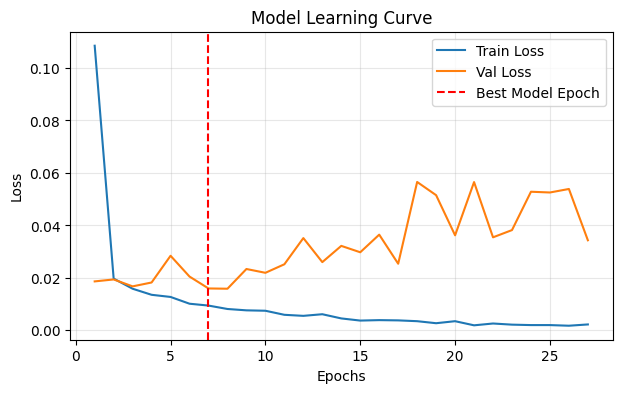

In [143]:
# Plot model learning curve
plt.figure(figsize=(7, 4))
plt.title('Model Learning Curve')
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Val Loss')
plt.axvline(x=early_stopping.best_epoch, color='r', linestyle='--', label=f'Best Model Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [144]:
# evaluate model
y_pred = []
y_true = []
y_scores = []

model.eval()
with torch.no_grad():
    for X_test_batch, y_test_batch in test_loader:
        X_test_batch, y_test_batch = X_test_batch.to(device).float(), y_test_batch.to(device)
        y_true.append(y_test_batch.cpu().numpy())
        logits = model(X_test_batch)
        probs = torch.sigmoid(logits)
        y_scores.append(probs.cpu().numpy()) # save probability scores
        preds = (probs > 0.5).cpu().numpy().astype(int)
        y_pred.append(preds)

In [145]:
y_true = [item[0] for sub_list in y_true for item in sub_list]
y_pred = [item[0] for sub_list in y_pred for item in sub_list]
y_scores = [item[0] for sub_list in y_scores for item in sub_list]

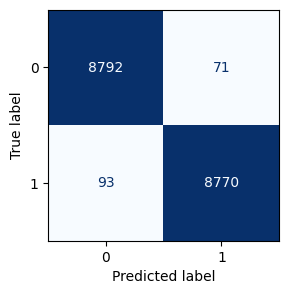

----------------- Classification Report -----------------

              precision    recall  f1-score   support

           0     0.9895    0.9920    0.9908      8863
           1     0.9920    0.9895    0.9907      8863

    accuracy                         0.9907     17726
   macro avg     0.9908    0.9907    0.9907     17726
weighted avg     0.9908    0.9907    0.9907     17726



In [146]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap='Blues', colorbar=None)
fig = disp.figure_
fig.set_figwidth(3)
fig.set_figheight(3) 
plt.grid(False)
plt.show()

# print classification report
print("----------------- Classification Report -----------------\n")
print(classification_report(y_true,y_pred, digits=4))

In [137]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)
roc_auc

0.9994788853337557

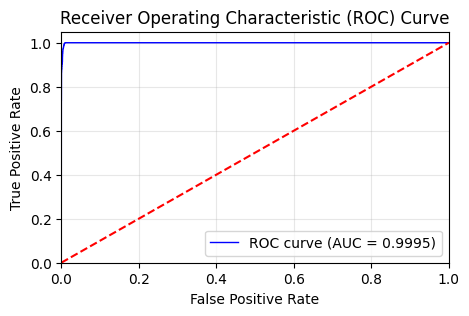

In [138]:
# Plot ROC curve
plt.figure(figsize=(5, 3))
plt.plot(fpr, tpr, color='blue', lw=1, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Define model version
version = 'v1'

In [ ]:
# Saving model

torch.save(model, f'../models/transformer_model_{version}.pt')

# Save training history
with open(f'../models/transformer_train_histories.txt', 'a') as f:
    text = f"version={version}, seed={SEED}, best_epochs={early_stopping.best_epoch}, auc={roc_auc:.4f}\n"
    text += f"d_model={d_model}, num_heads={num_heads}, num_layers={num_layers}, dim_feedforward={dim_feedforward}\n"
    text += f"tl_dropout={tl_dropout}, nn_dropout={nn_dropout}, lr={lr}\n"
    text += f"{classification_report(y_true,y_pred, digits=4)}\n"
    text += f"{'-'*75}\n"
    f.write(text)